In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
df = pd.read_csv("output/cleaned_movie_released_nonzero.csv")
df.drop(columns=['budget'], inplace=True)
released = df.copy()
released.head()


,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,original_language,original_title,...,production_countries_United States of America,production_countries_France,production_countries_Japan,production_countries_Germany,production_countries_United Kingdom,spoken_languages_English,spoken_languages_French,spoken_languages_Spanish,spoken_languages_Japanese,spoken_languages_German
0,Inception,8.364,34495,Released,2010-07-15,825532764,148,0,en,Inception,...,1,0,0,0,1,1,1,0,1,0
1,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,0,en,Interstellar,...,1,0,0,0,1,1,0,0,0,0
2,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,0,en,The Dark Knight,...,1,0,0,0,1,1,0,0,0,0
3,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,0,en,Avatar,...,1,0,0,0,1,1,0,1,0,0
4,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,0,en,The Avengers,...,1,0,0,0,0,1,0,0,0,0


Input Features

In [22]:
input_columns = [
    # 'release_date', 
    # 'release_season', 
    'release_year', 
    'release_quarter', 
    'release_month',
    # 'budget'
]

for prefix in ['genre_', 'production_companies_', 'production_countries_', 'spoken_languages_']:
    input_columns.extend([col for col in df.columns if col.startswith(prefix)])

X = df[input_columns]

Target Outputs

In [23]:
y_revenue = df['revenue']
y_popularity = df['popularity']
y_vote_count = df['vote_count']
y_vote_average = df['vote_average']

Train-Test Split

In [24]:
X_train_revenue, X_test_revenue, y_train_revenue, y_test_revenue = train_test_split(X, y_revenue, test_size=0.1)
X_train_popularity, X_test_popularity, y_train_popularity, y_test_popularity = train_test_split(X, y_popularity, test_size=0.1)
X_train_vote_count, X_test_vote_count, y_train_vote_count, y_test_vote_count = train_test_split(X, y_vote_count, test_size=0.1)
X_train_vote_average, X_test_vote_average, y_train_vote_average, y_test_vote_average = train_test_split(X, y_vote_average, test_size=0.1)

Training the Models

In [25]:
gbr_revenue = GradientBoostingRegressor()
gbr_revenue.fit(X_train_revenue, y_train_revenue)
y_pred_revenue = gbr_revenue.predict(X_test_revenue)

gbr_popularity = GradientBoostingRegressor()
gbr_popularity.fit(X_train_popularity, y_train_popularity)
y_pred_popularity = gbr_popularity.predict(X_test_popularity)

gbr_vote_count = GradientBoostingRegressor()
gbr_vote_count.fit(X_train_vote_count, y_train_vote_count)
y_pred_vote_count = gbr_vote_count.predict(X_test_vote_count)

gbr_vote_average = GradientBoostingRegressor()
gbr_vote_average.fit(X_train_vote_average, y_train_vote_average)
y_pred_vote_average = gbr_vote_average.predict(X_test_vote_average)

Evaluation of Models

In [26]:
print("\nrevenue")
print("mean_absolute_error: ", mean_absolute_error(y_test_revenue, y_pred_revenue))
print("mean_squared_error : ", mean_squared_error(y_test_revenue, y_pred_revenue))
print("r2_score           : ", r2_score(y_test_revenue, y_pred_revenue))

print("\npopularity")
print("mean_absolute_error: ", mean_absolute_error(y_test_popularity, y_pred_popularity))
print("mean_squared_error : ", mean_squared_error(y_test_popularity, y_pred_popularity))
print("r2_score           : ", r2_score(y_test_popularity, y_pred_popularity))

print("\nvote_count")
print("mean_absolute_error: ", mean_absolute_error(y_test_vote_count, y_pred_vote_count))
print("mean_squared_error : ", mean_squared_error(y_test_vote_count, y_pred_vote_count))
print("r2_score           : ", r2_score(y_test_vote_count, y_pred_vote_count))

print("\nvote_average")
print("mean_absolute_error: ", mean_absolute_error(y_test_vote_average, y_pred_vote_average))
print("mean_squared_error : ", mean_squared_error(y_test_vote_average, y_pred_vote_average))
print("r2_score           : ", r2_score(y_test_vote_average, y_pred_vote_average))


revenue
mean_absolute_error:  60665306.786570504
mean_squared_error :  2.023534664525126e+16
r2_score           :  0.2781763490302358

popularity
mean_absolute_error:  12.056469581338503
mean_squared_error :  2173.121298465133
r2_score           :  0.4504270025887078

vote_count
mean_absolute_error:  1215.1437341949893
mean_squared_error :  4333517.229708782
r2_score           :  0.30896034916825654

vote_average
mean_absolute_error:  0.793266755631594
mean_squared_error :  1.2158362904024234
r2_score           :  0.18503398000825422


In [27]:
importances_revenue = pd.Series(gbr_revenue.feature_importances_, index=X.columns)
importances_revenue = importances_revenue.sort_values(ascending=False)
print("Revenue Importances:\n", importances_revenue)

importances_popularity = pd.Series(gbr_popularity.feature_importances_, index=X.columns)
importances_popularity = importances_popularity.sort_values(ascending=False)
print("\nPopularity Importances:\n", importances_popularity)

importances_vote_count = pd.Series(gbr_vote_count.feature_importances_, index=X.columns)
importances_vote_count = importances_vote_count.sort_values(ascending=False)
print("\nVote Count Importances:\n", importances_vote_count)

importances_vote_average = pd.Series(gbr_vote_average.feature_importances_, index=X.columns)
importances_vote_average = importances_vote_average.sort_values(ascending=False)
print("\nVote Average Importances:\n", importances_vote_average)

Revenue Importances:
 genre_Adventure                                  0.259766
release_year                                     0.244168
production_countries_United States of America    0.164936
release_month                                    0.061121
genre_Fantasy                                    0.040227
genre_Science Fiction                            0.038877
genre_Animation                                  0.036772
genre_Action                                     0.034550
production_companies_Warner Bros. Pictures       0.016611
genre_Family                                     0.015473
genre_Drama                                      0.014955
spoken_languages_English                         0.009643
production_companies_Columbia Pictures           0.008882
spoken_languages_French                          0.007594
release_quarter                                  0.007543
production_countries_United Kingdom              0.007237
genre_Comedy                                     0

GridSearchCV (Testing Out Different Parameters for GradientBoostingRegressor)

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [1, 2, 3, 4],
    'min_samples_split': [2, 3, 4]
}

gbr_cv = GridSearchCV(gbr_revenue, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
gbr_cv.fit(X_train_revenue, y_train_revenue)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.1], 'max_depth': [3, 4, 5],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [100]},
             scoring='neg_mean_squared_error')

In [29]:
y_pred_revenue = gbr_cv.predict(X_test_revenue)
print(mean_absolute_error(y_test_revenue, y_pred_revenue))
print(mean_squared_error(y_test_revenue, y_pred_revenue))
print(r2_score(y_test_revenue, y_pred_revenue))
print(gbr_cv.best_params_)

58449163.504293405
1.9379846713119596e+16
0.30869325072910436
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 100}


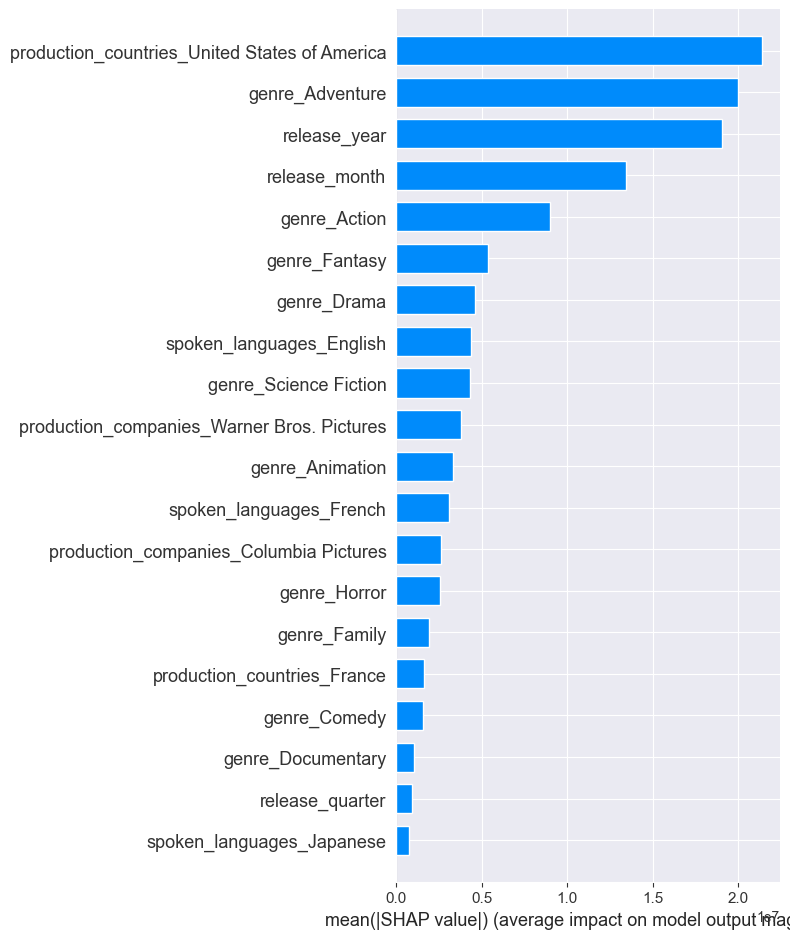

ValueError: Could not find feature named: budget

<Figure size 1200x800 with 0 Axes>

In [30]:
import shap
import matplotlib.pyplot as plt

# SHAP values for better feature importance understanding
explainer = shap.TreeExplainer(gbr_revenue)
shap_values = explainer.shap_values(X_test_revenue)

# SHAP summary plot (no need for plt.figure here)
shap.summary_plot(shap_values, X_test_revenue, plot_type="bar")

# SHAP dependence plot (this one can use plt.figure)
plt.figure(figsize=(12, 8))
shap.dependence_plot("budget", shap_values, X_test_revenue)

# Analyze feature importance by genre
def feature_importance_by_genre(model, X, genre_col):
    genre_mask = X[genre_col] == 1
    X_genre = X[genre_mask]
    
    # Get feature importances for just this genre's movies
    if len(X_genre) > 10:  # Only analyze if enough samples
        importances = pd.Series(model.feature_importances_, index=X.columns)
        importances = importances.sort_values(ascending=False)
        
        # Plot top 10 features
        plt.figure(figsize=(10, 6))
        importances[:10].plot(kind='bar')
        plt.title(f'Feature Importance for {genre_col.replace("genre_", "")}')
        plt.tight_layout()
        plt.show()
        
        return importances
    return None

# Example usage for a specific genre
feature_importance_by_genre(gbr_revenue, X, 'genre_Action')

In [ ]:
# Create a new target for ROI
df['roi'] = (df['revenue'] - df['budget']) / df['budget']
y_roi = df['roi']

# Split data
X_train_roi, X_test_roi, y_train_roi, y_test_roi = train_test_split(X, y_roi, test_size=0.1, random_state=42)

# Train ROI model
gbr_roi = GradientBoostingRegressor()
gbr_roi.fit(X_train_roi, y_train_roi)
y_pred_roi = gbr_roi.predict(X_test_roi)

# Evaluate
print("\nROI Prediction Results:")
print("MAE:", mean_absolute_error(y_test_roi, y_pred_roi))
print("R²:", r2_score(y_test_roi, y_pred_roi))

# Find the most important features for ROI
importances_roi = pd.Series(gbr_roi.feature_importances_, index=X.columns)
importances_roi = importances_roi.sort_values(ascending=False)
print("\nROI Feature Importances:")
print(importances_roi[:10])

In [ ]:
'''
0.5668896280610903
{'criterion': 'friedman_mse',
 'learning_rate': 0.01,
 'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 300}

49725670.23436365
1.3831595103615548e+16
0.5661379683786802
{'learning_rate': 0.01,
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 4,
 'n_estimators': 300}

49470636.75543827
1.386009389191735e+16
0.5652440337240913
{'learning_rate': 0.01,
 'max_depth': 5,
 'min_samples_leaf': 6,
 'min_samples_split': 3,
 'n_estimators': 300}

49858141.79351606
1.4097237970131422e+16
0.5578054258997466
{'learning_rate': 0.01,
 'max_depth': 5,
 'min_samples_leaf': 2,
 'min_samples_split': 4,
 'n_estimators': 300}

49830392.0367167
1.407046087210932e+16
0.558645355500184
{'learning_rate': 0.01,
 'max_depth': 5,
 'min_samples_leaf': 2,
 'min_samples_split': 4,
 'n_estimators': 300}

49847806.99900844
1.4092120649101166e+16
0.5579659432718944
{'learning_rate': 0.01,
 'max_depth': 5,
 'min_samples_leaf': 2,
 'min_samples_split': 4,
 'n_estimators': 300}

49655821.13375789
1.3569761623000274e+16
0.5743510200907369
{'learning_rate': 0.1,
 'max_depth': 3,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

49663860.925762735
1.3863652549843808e+16
0.5651324076573758
{'learning_rate': 0.1,
 'max_depth': 4,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 100}
'''